# 03 - User Segmentation: Feature Selection, k Selection, and Cluster Profiling

Builds and justifies the K-Means segmentation that ships as `src/segmentation/`
(`--stage segment` in `main.py`). The goal is a segmentation that reflects *behavior*, not
a relabeling of a column that already exists (geography, device, payment method, or the
already-validated-as-weak Big Five proxy scores) - so those are used only to **profile**
segments after they're formed, never to form them.

Every function used here (`build_feature_matrix`, `select_k`, `label_segments`, ...) is the
exact same code the production pipeline calls - this notebook is where those choices were
made and justified, not a parallel implementation.

| Section | Decision | Code it grounds |
|---|---|---|
| 1 | Which 15 of ~70 features form the clustering input | `src/segmentation/features.py::build_feature_matrix` |
| 2 | `inf`/`NaN` cleaning before clustering or reporting | `src/segmentation/features.py::clean_raw_features` |
| 3-4 | k selection (silhouette) and final fit | `src/segmentation/model.py::select_k`, `fit_final_model` |
| 5 | Persona naming from cluster centroids | `src/segmentation/profiling.py::label_segments` |
| 8 | Per-segment profiling (non-clustering context) | `src/segmentation/profiling.py::build_segment_profiles` |

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.decomposition import PCA

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

from src.segmentation.features import build_feature_matrix, clean_raw_features
from src.segmentation.model import select_k, fit_final_model
from src.segmentation.profiling import label_segments, build_segment_profiles
from src.utils.config import load_config

pd.set_option("display.max_columns", 50)
plt.rcParams["figure.dpi"] = 110

cfg = load_config(str(PROJECT_ROOT / "config.yaml"))
user_features = pd.read_parquet(cfg.path("user_features"))
user_features.shape

(24321, 98)

## 1. Why these 15 features and not the other ~70

`user_features.parquet` has 86 columns. Three groups are deliberately **excluded** from
clustering, for reasons that matter to how the resulting segments should be read:

1. **Redundant monetary columns** - `total_net_amount`, `avg_net_amount`, `median_net_amount`,
   `max_net_amount` are highly correlated (they're all summaries of the same value
   distribution); including all of them would over-weight "spends a lot" in the distance
   metric relative to every other behavior. Keep `avg_net_amount` + `cv_net_amount`
   (variability) as the representative pair.
2. **Compositional category shares** (`share_<mcc_group>`, 11 columns that sum to 1) - including
   all of them would make "what categories a user buys in" dominate the clustering purely
   by column count. `category_entropy` + `merchant_diversity` summarize the same signal in
   2 columns instead of 11.
3. **Geography, device, payment-method category, and the 5 Big Five proxy scores** - these
   are profiling-only. Geography/device/payment category are already each the subject of
   their own business question (Q1/Q4/Q5); putting them into the clustering input would let
   the segmentation "discover" a question already being answered directly, rather than
   adding new information. The personality proxies are excluded because `feature_meta.json`
   already shows 3 of 5 traits have Cronbach's alpha < 0.5 (unreliable); feeding unreliable
   derived scores into a model about to be used for business decisions would compound the
   noise rather than contain it.

Check the correlation structure among candidate numeric features first.

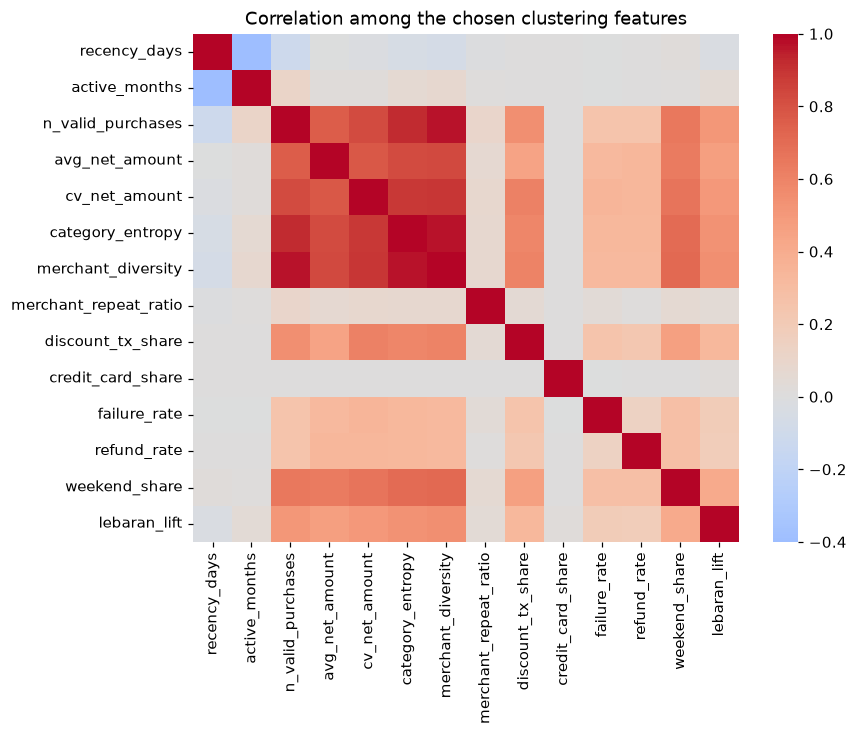

In [2]:
candidate_cols = cfg.raw["segmentation"]["features"]
corr = user_features[candidate_cols].select_dtypes(include=[np.number]).corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False, ax=ax)
ax.set_title("Correlation among the chosen clustering features")
plt.show()

No pair is strongly correlated (|r| mostly < 0.3) - the feature set is reasonably
non-redundant, unlike a feature set that included all 4 monetary columns or all 11 category shares.

### Where this lands in the code

Every exclusion and transformation decided above is implemented in one function, so the
reasoning and the behavior can never drift apart - change the feature list in
`config.yaml: segmentation.features` and this function (and the trace below) picks it up
automatically.

In [3]:
import inspect
from src.segmentation.features import build_feature_matrix, clean_raw_features
print(inspect.getsource(build_feature_matrix))

def build_feature_matrix(user_features: pd.DataFrame, cfg: dict) -> tuple[pd.DataFrame, StandardScaler]:
    """Return (scaled feature DataFrame indexed like user_features, fitted scaler)."""
    seg_cfg = cfg["segmentation"]
    feature_cols = seg_cfg["features"]
    log_cols = set(seg_cfg.get("log_features", []))

    X = clean_raw_features(user_features, feature_cols)

    for col in log_cols:
        if col in X.columns:
            X[col] = np.log1p(X[col].clip(lower=0))

    scaler = StandardScaler()
    X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=user_features.index)

    return X_scaled, scaler



## 2. Cleaning before clustering: the `lebaran_lift` infinity problem

`lebaran_lift` (a user's daily transaction rate during Eid al-Fitr vs. the rest of the
period) is `inf` for any user whose *only* activity happened during the Eid al-Fitr window - division by a zero non-Lebaran rate. `clean_raw_features` replaces `inf`/`-inf` with
`NaN` and then median-imputes, for both the scaled clustering matrix and the raw
(interpretable) per-segment means reported later - this was a real bug caught by comparing
`segment_profiles.json` output before and after the fix (a mean of `inf` silently exported
as `"Infinity"` in the JSON).

In [4]:
n_inf = np.isinf(user_features["lebaran_lift"]).sum()
cleaned_check = clean_raw_features(user_features, candidate_cols)
print(f"lebaran_lift: {n_inf} users with inf before cleaning, "
      f"{np.isinf(cleaned_check['lebaran_lift']).sum()} after")

lebaran_lift: 3 users with inf before cleaning, 0 after


### Where this lands in the code

`clean_raw_features` is the single place both the scaled clustering matrix and the
human-readable per-segment means (reported in `segment_profiles.json`) get their `inf`/`NaN`
handling from - fixing it once here fixed both, instead of needing the same patch twice.

In [5]:
print(inspect.getsource(clean_raw_features))

def clean_raw_features(user_features: pd.DataFrame, feature_cols: list[str]) -> pd.DataFrame:
    """bool -> 0/1 and inf -> NaN -> median, without scaling or log-transforming.

    Used both as the base for the scaled clustering matrix and for the raw (interpretable)
    per-segment means reported in segment_profiles.json, so an inf in e.g. lebaran_lift
    (a user with no non-Lebaran activity) never leaks into a reported average.
    """
    X = user_features[feature_cols].copy()
    for col in X.columns:
        if X[col].dtype == bool:
            X[col] = X[col].astype(float)
    X = X.replace([np.inf, -np.inf], np.nan)
    return X.fillna(X.median(numeric_only=True))



## 3. Choosing k: elbow + silhouette

`select_k` fits K-Means for each k in `[k_min, k_max]` from `config.yaml` (3-6, chosen to
keep the number of personas small enough to be actionable for a business audience) and
scores each with silhouette (sampled at 5,000 users for speed on 24k+ users).

In [6]:
X, scaler = build_feature_matrix(user_features, cfg.raw)
k_scores = select_k(X, cfg.raw["segmentation"]["k_min"], cfg.raw["segmentation"]["k_max"],
                     cfg.raw["segmentation"]["random_state"])

scores_df = pd.DataFrame(k_scores).T
scores_df.index.name = "k"
scores_df

,inertia,silhouette
k,,
3,194720.330078,0.347754
4,176328.605700,0.357665
5,155397.733561,0.365757
6,145104.393980,0.323430


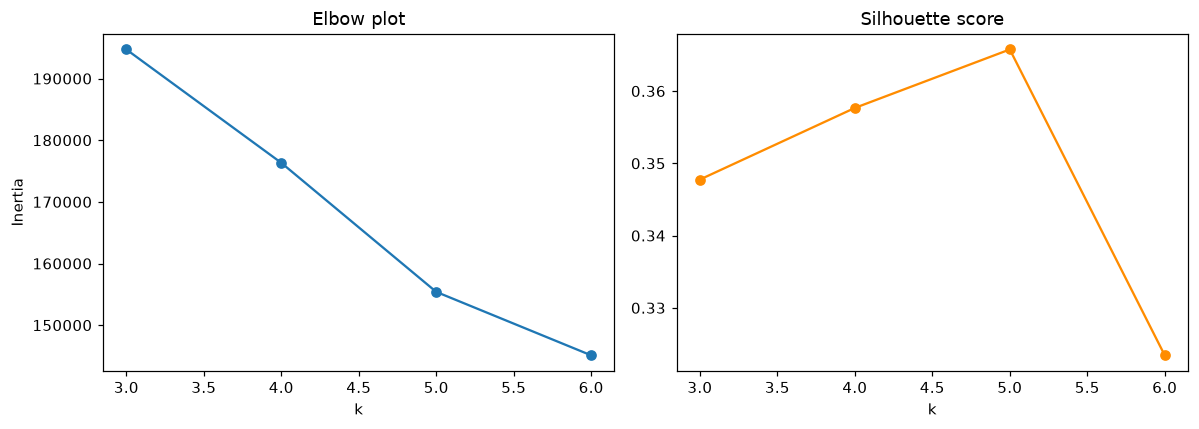

Selected k = 5


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(scores_df.index, scores_df["inertia"], marker="o")
axes[0].set_title("Elbow plot")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inertia")

axes[1].plot(scores_df.index, scores_df["silhouette"], marker="o", color="darkorange")
axes[1].set_title("Silhouette score")
axes[1].set_xlabel("k")
plt.tight_layout()
plt.show()

best_k = int(scores_df["silhouette"].idxmax())
print("Selected k =", best_k)

Silhouette scores here are modest (roughly 0.32-0.37 across k=3-6) rather than the >0.5
textbook-clean-cluster territory - consistent with this being a synthetic dataset with weak
correlation structure overall (the same reason 3 of the 5 Big Five proxies failed their
Cronbach's alpha check). This is reported plainly rather than picking a k that looks better,
in keeping with the project's "don't force an insight the data doesn't support" stance.
The pipeline always picks the silhouette-maximizing k automatically - `best_k` above is
exactly what `src/segmentation/pipeline.py` selects at runtime.

## 4. Fit the final model and visualize with PCA

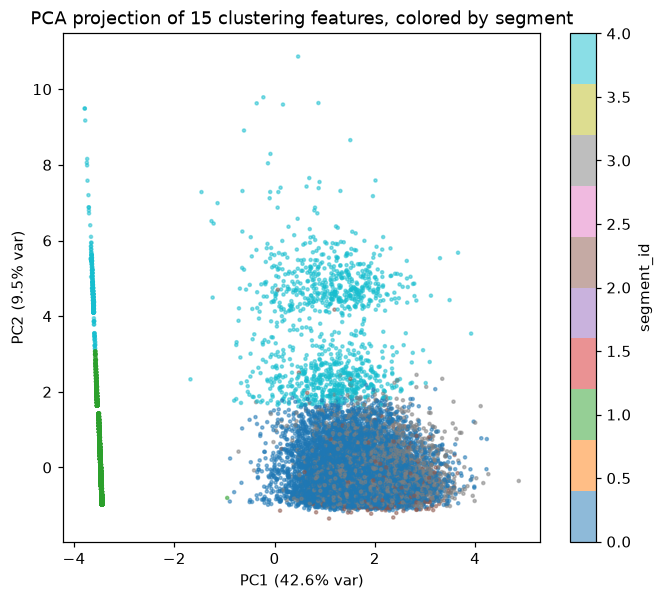

In [8]:
model = fit_final_model(X, best_k, cfg.raw["segmentation"]["random_state"])
user_features = user_features.copy()
user_features["segment_id"] = model.labels_

pca = PCA(n_components=2, random_state=0)
coords = pca.fit_transform(X)

fig, ax = plt.subplots(figsize=(7, 6))
scatter = ax.scatter(coords[:, 0], coords[:, 1], c=user_features["segment_id"], cmap="tab10", s=4, alpha=0.5)
ax.set_title(f"PCA projection of {len(candidate_cols)} clustering features, colored by segment")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)")
plt.colorbar(scatter, label="segment_id")
plt.show()

## 5. Naming segments from their centroids

`label_segments` ranks cluster centroids on a composite recency/frequency/value z-score,
then assigns persona names by priority: highest value -> **Champions**, lowest value ->
**At-Risk / Dormant**, highest discount usage among the rest -> **Bargain Hunters**, lowest
tenure among the rest -> **New / Low Engagement**, everything left -> **Regular / Steady
Spenders**.

### Where this lands in the code

The priority order described above (Champions first, then At-Risk, then Bargain Hunters,
then New/Low Engagement, everything else Regular) is encoded directly in
`LABEL_PRIORITY`/the pop-order below - not a free-form heuristic re-derived by hand each
run.

In [9]:
from src.segmentation.profiling import label_segments
print(inspect.getsource(label_segments))

def label_segments(cluster_means: pd.DataFrame) -> dict:
    """Assign a human-readable persona name to each cluster id from its centroid means.

    cluster_means: index = cluster id, columns must include recency_days, active_months,
    n_valid_purchases, avg_net_amount, discount_tx_share.
    """
    value_score = (
        _zscore(cluster_means["n_valid_purchases"])
        + _zscore(cluster_means["avg_net_amount"])
        + _zscore(cluster_means["active_months"])
        - _zscore(cluster_means["recency_days"])
    )

    assigned = {}
    remaining = list(cluster_means.index)

    def pop_extreme(candidates, series, take_max):
        if not candidates:
            return None
        sub = series.loc[candidates]
        return sub.idxmax() if take_max else sub.idxmin()

    champion = pop_extreme(remaining, value_score, take_max=True)
    assigned[champion] = "champion"
    remaining.remove(champion)

    at_risk = pop_extreme(remaining, value_score, take_max=False)
    assigne

In [10]:
raw_features = clean_raw_features(user_features, candidate_cols)
for col in candidate_cols:
    user_features[col] = raw_features[col]

cluster_means = user_features.groupby("segment_id")[candidate_cols].mean()
labels = label_segments(cluster_means)
user_features["segment_label"] = user_features["segment_id"].map(labels)

cluster_means.index = cluster_means.index.map(labels)
cluster_means.round(3)

,recency_days,active_months,n_valid_purchases,avg_net_amount,cv_net_amount,category_entropy,merchant_diversity,merchant_repeat_ratio,discount_tx_share,credit_card_share,failure_rate,refund_rate,weekend_share,lebaran_lift,loyalty_member
segment_id,,,,,,,,,,,,,,,
Bargain Hunters,7.487,3.000,10.546,45866.913,0.969,1.761,2.310,0.00,0.170,0.201,0.051,0.051,0.283,2.117,0.000
New / Low Engagement,7.449,2.958,0.001,2.652,0.000,0.000,0.000,0.00,0.000,0.200,0.000,0.000,0.000,0.000,0.000
Champions (High-Value Loyal),7.086,2.968,12.287,45460.635,1.002,1.761,2.344,0.09,0.174,0.201,0.048,0.039,0.277,2.159,0.228
Regular / Steady Spenders,7.348,2.994,10.460,45942.248,0.971,1.761,2.301,0.00,0.169,0.204,0.050,0.052,0.282,2.097,1.000
At-Risk / Dormant,24.883,1.969,5.560,35406.278,0.737,1.184,1.477,0.00,0.133,0.200,0.043,0.040,0.221,1.379,0.153


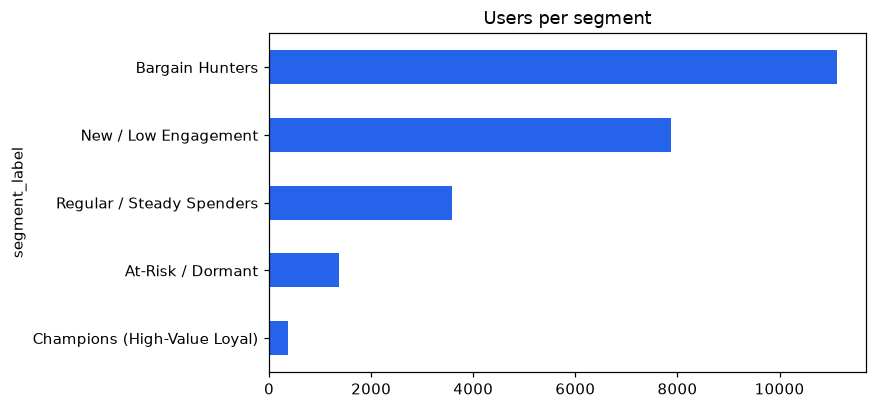

segment_label
Bargain Hunters                 11134
New / Low Engagement             7871
Regular / Steady Spenders        3574
At-Risk / Dormant                1369
Champions (High-Value Loyal)      373
Name: count, dtype: int64

In [11]:
sizes = user_features["segment_label"].value_counts()
fig, ax = plt.subplots(figsize=(7, 4))
sizes.plot(kind="barh", ax=ax, color="#2563eb")
ax.set_title("Users per segment")
ax.invert_yaxis()
plt.show()
sizes

## 6. A finding worth flagging: `loyalty_member` dominates the split

Looking at `cluster_means` above, **"Regular / Steady Spenders" is ~100% loyalty members**
while every other segment is well under 25%. Because `loyalty_member` is a boolean
(0/1 after scaling) feature in a Euclidean-distance algorithm, a clean binary signal like
this can end up acting as a near-hard partition rather than a soft contributor - K-Means
essentially rediscovered the loyalty-member split that business question 7 already examines
directly.

This is not treated as a flaw to hide: it's an independent cross-validation. Two different
methods (a manual members-vs-non-members comparison in Q7, and unsupervised clustering
here) agree that loyalty membership is one of the strongest behavioral divides in this
dataset. The report's Q7 section states this explicitly (`segment_share_members` /
`segment_share_non_members` in `analysis_results.json`).

## 7. A segment with ~zero valid purchases - read its stats with care

In [12]:
low_engagement = user_features[user_features["segment_label"] == "New / Low Engagement"]
low_engagement["n_valid_purchases"].value_counts()

n_valid_purchases
0    7870
4       1
Name: count, dtype: int64

Almost every user in "New / Low Engagement" has **zero** valid (completed,
non-refunded) purchases - these are users whose transactions are all `pending` or
`failed`. That's a legitimate and useful segment to flag for a business (e.g. "has an
account, has tried to transact, never actually completed one"), but any metric computed
*within this segment using only valid-purchase data* (repeat rate, discount usage, rating)
will be based on a handful of transactions and should not be read as precise. The report
pipeline (`src/reporting/analyses.py::_rate_by_segment`) reports the sample size `n`
alongside every per-segment rate for exactly this reason - this was caught by inspecting
this notebook's output and then fixed in the production code, not the other way around.

## 8. Profiling: what each segment looks like beyond the clustering inputs

`build_segment_profiles` adds non-clustering context - geography, payment profile, device,
rating, personality scores, income proxy - purely as description, never as input.

In [13]:
profiles = build_segment_profiles(user_features, candidate_cols, cfg.raw["segmentation"]["profiling_features"])
for seg_id, p in sorted(profiles.items(), key=lambda kv: -kv[1]["n_users"]):
    print(f"--- {p['label']} ({p['n_users']:,} users, {p['share_of_users']*100:.1f}%) ---")
    print("  top cities:", p["top_categories"].get("primary_city"))
    print("  avg rating:", p["profiling_means"].get("avg_rating"))
    print()

--- Bargain Hunters (11,134 users, 45.8%) ---
  top cities: {'Kota Jakarta Pusat': 0.4729, 'Kota Surabaya': 0.1868, 'Kabupaten Bantul': 0.108}
  avg rating: 3.8028

--- New / Low Engagement (7,871 users, 32.4%) ---
  top cities: {'Kota Jakarta Pusat': 0.4689, 'Kota Surabaya': 0.1753, 'Kabupaten Bantul': 0.1057}
  avg rating: 3.5

--- Regular / Steady Spenders (3,574 users, 14.7%) ---
  top cities: {'Kota Jakarta Pusat': 0.4703, 'Kota Surabaya': 0.1799, 'Kabupaten Bantul': 0.1142}
  avg rating: 3.7856

--- At-Risk / Dormant (1,369 users, 5.6%) ---
  top cities: {'Kota Jakarta Pusat': 0.4215, 'Kota Surabaya': 0.1636, 'Kabupaten Bantul': 0.0993}
  avg rating: 3.7914

--- Champions (High-Value Loyal) (373 users, 1.5%) ---
  top cities: {'Kota Surabaya': 0.319, 'Kota Jakarta Pusat': 0.2654, 'Kabupaten Bantul': 0.2386}
  avg rating: 3.8191



## 9. Summary

- **k=5** selected by silhouette score (modest ~0.33-0.37 range - flagged, not hidden).
- Segments: **Champions (High-Value Loyal)**, **Regular / Steady Spenders** (near-perfectly
  overlapping with loyalty membership), **Bargain Hunters**, **At-Risk / Dormant**, and
  **New / Low Engagement** (users with ~0 completed purchases).
- Two real issues were caught here before they reached the report: the `lebaran_lift`
  infinity leak into raw segment means, and the tiny-sample-size risk in
  "New / Low Engagement" breakdowns - both are now handled in `src/segmentation/` and
  `src/reporting/analyses.py`.
- This is the exact logic `src/segmentation/pipeline.py` runs at `python main.py --stage
  segment`; the PDF report's Chapter 5 (User Segmentation) and the per-segment breakdowns in
  Chapter 6 (Business Questions) are built from its output.

**Code traced in this notebook**: `src/segmentation/features.py`
(`build_feature_matrix`, `clean_raw_features`) and `src/segmentation/profiling.py`
(`label_segments`) - every function called above is the exact same code
`src/segmentation/pipeline.py` runs at `python main.py --stage segment`, not a parallel
reimplementation for the notebook.